# Inequality in Denmark

#%pip install git+https://github.com/alemartinello/dstapi
#%pip install fredapi


In [72]:
import numpy as np
import pandas as pd

# APIs
from fredapi import Fred
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

In [73]:
IFOR41 = DstApi('IFOR41') 

In [74]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [75]:
IFOR41.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


In [76]:
print(IFOR41.variable_levels('KOMMUNEDK', language='en'))

     id             text
0   000      All Denmark
1   101       Copenhagen
2   147    Frederiksberg
3   155           Dragør
4   185           Tårnby
..  ...              ...
94  773            Morsø
95  840           Rebild
96  787          Thisted
97  820  Vesthimmerlands
98  851          Aalborg

[99 rows x 2 columns]


In [77]:
kommune = IFOR41.variable_levels('KOMMUNEDK', language='en')

print(kommune)

     id             text
0   000      All Denmark
1   101       Copenhagen
2   147    Frederiksberg
3   155           Dragør
4   185           Tårnby
..  ...              ...
94  773            Morsø
95  840           Rebild
96  787          Thisted
97  820  Vesthimmerlands
98  851          Aalborg

[99 rows x 2 columns]


In [78]:
IFOR41.variable_levels('ULLIG', language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [79]:
print(IFOR41.variable_levels('ULLIG', language='en'))

   id                                             text
0  70                                 Gini coefficient
1  71                                     Hoover index
2  72            S80/S20 (Income quintile share ratio)
3  73  P90/10 (Upper decile boundary divided by lower)


In [80]:
IFOR41.variable_levels('Tid', language='en')

,id,text
0,1987,1987
1,1988,1988
2,1989,1989
3,1990,1990
4,1991,1991
5,1992,1992
6,1993,1993
7,1994,1994
8,1995,1995
9,1996,1996


In [81]:
gini = IFOR41.get_data(
    params={
        'table': 'IFOR41',
        'format': 'BULK',
        'lang': 'en',
        'variables': [
            {
                'code': 'KOMMUNEDK',
                'values': ["000"]
            },
            {
                'code': 'ULLIG',
                'values': ["70"]
            },
            {
                'code': 'Tid',
                'values': ["*"]
            }
        ]
    }
)

print(gini.head())
print(gini.columns)

     KOMMUNEDK             ULLIG   TID INDHOLD
0  All Denmark  Gini coefficient  2016   28.97
1  All Denmark  Gini coefficient  1999   23.83
2  All Denmark  Gini coefficient  1988   22.06
3  All Denmark  Gini coefficient  2015   28.77
4  All Denmark  Gini coefficient  1989   21.93
Index(['KOMMUNEDK', 'ULLIG', 'TID', 'INDHOLD'], dtype='object')


In [82]:
print(gini.head())
print(gini.columns.tolist())

     KOMMUNEDK             ULLIG   TID INDHOLD
0  All Denmark  Gini coefficient  2016   28.97
1  All Denmark  Gini coefficient  1999   23.83
2  All Denmark  Gini coefficient  1988   22.06
3  All Denmark  Gini coefficient  2015   28.77
4  All Denmark  Gini coefficient  1989   21.93
['KOMMUNEDK', 'ULLIG', 'TID', 'INDHOLD']


The Gini coefficient measures income inequality in the population. Higher Gini coefficient means more inequality

In [83]:
# 1. Rename the two columns
gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

# 2. Convert year and Gini to numbers
gini['year'] = pd.to_numeric(gini['year'])
gini['gini'] = pd.to_numeric(gini['gini'])

# 3. Sort by year
gini = gini.sort_values('year')

# 4. Check the result
print(gini[['year', 'gini']].head())


    year   gini
16  1987  22.07
2   1988  22.06
4   1989  21.93
30  1990  22.16
25  1991  21.99


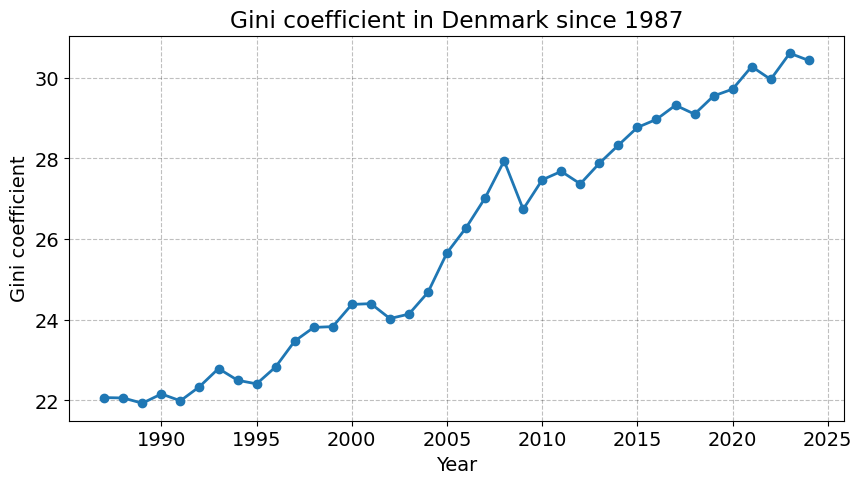

In [206]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    gini["year"],
    gini["gini"],
    marker="o",
    linewidth=2
)

ax.set_title("Gini coefficient in Denmark since 1987")
ax.set_xlabel("Year")
ax.set_ylabel("Gini coefficient")

plt.show()

## 1.2 Create the IFOR32 table 

In [85]:
IFOR32 = DstApi ('IFOR32')

IFOR32.tablesummary(language='en')


Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [86]:
IFOR32.variable_levels('DECILGEN', language='en')

,id,text
0,1DC,First decil
1,2DC,Second decil
2,3DC,Third decil
3,4DC,Fourth decil
4,5DC,Fifth decil
5,6DC,Sixth decil
6,7DC,Seventh decil
7,8DC,Eigth decil
8,9DC,Ninth decil
9,10DC,Tenth decil


In [87]:
IFOR32.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


In [88]:
KOMMUNEDK = "000"

In [89]:
top10 = IFOR32.get_data(
    params={
        'table': 'IFOR32',
        'format': 'BULK',
        'lang': 'en',
        'variables': [
            {
                'code': 'KOMMUNEDK',
                'values': ['000']
            },
            {
                'code': 'DECILGEN',
                'values': ['10DC']
            },
            {
                'code': 'Tid',
                'values': ['*']
            }
        ]
    }
)

print(top10.head())
print(top10.columns.tolist())

     KOMMUNEDK     DECILGEN   TID  INDHOLD
0  All Denmark  Tenth decil  1987   169598
1  All Denmark  Tenth decil  1988   178357
2  All Denmark  Tenth decil  1989   188967
3  All Denmark  Tenth decil  1990   197793
4  All Denmark  Tenth decil  1991   207208
['KOMMUNEDK', 'DECILGEN', 'TID', 'INDHOLD']


In [90]:
gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

gini['year'] = pd.to_numeric(gini['year'])
gini['gini'] = pd.to_numeric(gini['gini'])

In [91]:
top10 = top10.rename(columns={
    'TID': 'year',
    'INDHOLD': 'top10'
})

top10['year'] = pd.to_numeric(top10['year'])
top10['top10'] = pd.to_numeric(top10['top10'])

In [92]:
comparison = pd.merge(
    gini[['year', 'gini']],
    top10[['year', 'top10']],
    on='year',
    how='inner'
)

comparison = comparison.sort_values('year')

print(comparison.head())

   year   gini   top10
0  1987  22.07  169598
1  1988  22.06  178357
2  1989  21.93  188967
3  1990  22.16  197793
4  1991  21.99  207208


In [93]:
correlation = comparison['gini'].corr(comparison['top10'])

print("Correlation:", correlation)

Correlation: 0.9787337228215816


Which means there is a strong correlation

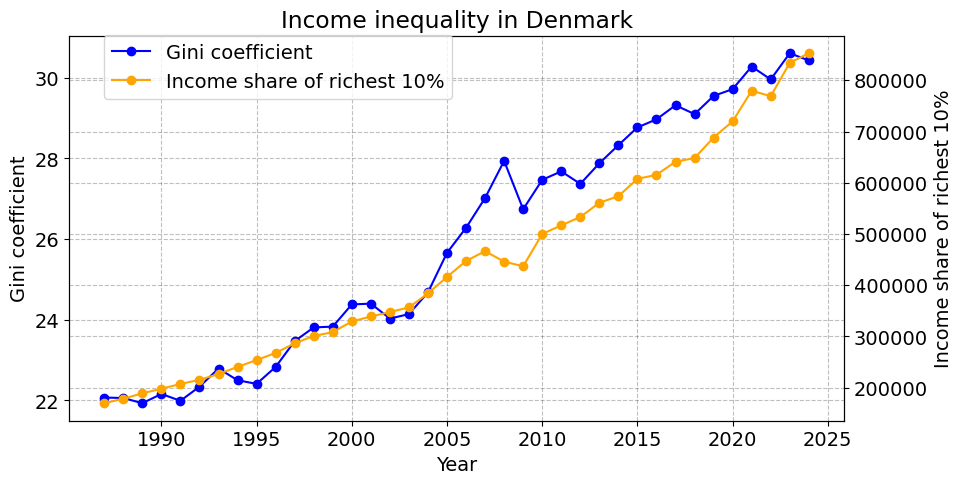

In [222]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    comparison['year'],
    comparison['gini'],
    marker='o',
    color ='blue',
    label='Gini coefficient'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Gini coefficient')


ax2 = ax1.twinx()

ax2.plot(
    comparison['year'],
    comparison['top10'],
    marker='o',
    color ='orange',
    label='Income share of richest 10%'
)

ax2.set_ylabel('Income share of richest 10%')
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.9))

ax1.set_title('Income inequality in Denmark')

plt.show()

Development since 1987:
* 1987-1995: The income inequality was quite low. The Gini coefficient was around 22-23, while the income share of the richest 10% was also fairly low. 

* 1995-2005: The inequality slowly increased and the gini coefficient increase from around 23 to 25-26, and the richest 10% have increase their income.

* 2005-2010: The inequality increased significantly up tp 2008, during to a decline around the 2008 financial crisis, where the gini coefficient rose to around 28, while the richest 10% have a slight increase.

* 2010-2020: The inequality has a ongoing steady rise. The Gini coefficient increased form around 27 to almost 30, while the income share of the richest 10% increased as well.

* 2020-2025: The inequality reached its highest level in this period, with a gini coefficient above 30, and the richest 10% has a significantly larger share of the total income.

Conclusion:
The development since 1987, the income inequality in Denmark has increased significantly. Both the gini coefficient and the income share of the richest 10% show a clear upward trend, with some short-term fluctuations, most notable around the 2008 financial crisis


## 1.2 Prediction

#### 1. Solve this minimization problem yourself with scipy.optimize.minimize.

Determine the linear

In [95]:
gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

# Convert to numeric
gini['year'] = pd.to_numeric(gini['year'])
gini['gini'] = pd.to_numeric(gini['gini'])

# Sort by year
gini = gini.sort_values('year')

# Keep observations from 1987 onwards
gini = gini[gini['year'] >= 1987].copy()

# t = number of years since 1987
gini['t'] = gini['year'] - 1987

print(gini[['year', 't', 'gini']].head())

    year  t   gini
16  1987  0  22.07
2   1988  1  22.06
4   1989  2  21.93
30  1990  3  22.16
25  1991  4  21.99


In [97]:
from scipy.optimize import minimize
import numpy as np

In [98]:
t = gini['t'].to_numpy()
y = gini['gini'].to_numpy()

In [99]:
def objective_linear(beta):
    beta0, beta1 = beta
    
    prediction = beta0 + beta1 * t
    
    return np.sum((y - prediction)**2)

In [100]:
result_linear = minimize(
    objective_linear,
    x0=[0, 0]
)

beta_linear = result_linear.x

print("Linear coefficients:")
print("beta0 =", beta_linear[0])
print("beta1 =", beta_linear[1])

Linear coefficients:
beta0 = 21.04275353962108
beta1 = 0.26354959491805635


Determine the quadratic

In [101]:
def objective_quadratic(beta):
    beta0, beta1, beta2 = beta
    
    prediction = beta0 + beta1 * t + beta2 * t**2
    
    return np.sum((y - prediction)**2)

In [102]:
result_quadratic = minimize(
    objective_quadratic,
    x0=[0, 0, 0]
)

beta_quadratic = result_quadratic.x

print("Quadratic coefficients:")
print("beta0 =", beta_quadratic[0])
print("beta1 =", beta_quadratic[1])
print("beta2 =", beta_quadratic[2])

Quadratic coefficients:
beta0 = 21.304188259289926
beta1 = 0.2199761164544483
beta2 = 0.0011776632990492272


### 2. Check your answer against np.polyfit. Do you get the same coefficients?

In [103]:
poly_linear = np.polyfit(t, y, 1)

print("np.polyfit linear:")
print(poly_linear)

np.polyfit linear:
[ 0.26354962 21.04275304]


In [104]:
poly_quadratic = np.polyfit(t, y, 2)

print("np.polyfit quadratic:")
print(poly_quadratic)

np.polyfit quadratic:
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


In [105]:
print("Linear comparison:")
print("minimize:", beta_linear)
print("polyfit: ", poly_linear[::-1])

print()

print("Quadratic comparison:")
print("minimize:", beta_quadratic)
print("polyfit: ", poly_quadratic[::-1])

Linear comparison:
minimize: [21.04275354  0.26354959]
polyfit:  [21.04275304  0.26354962]

Quadratic comparison:
minimize: [2.13041883e+01 2.19976116e-01 1.17766330e-03]
polyfit:  [2.13042004e+01 2.19975061e-01 1.17769085e-03]


3. Use your estimates to predict the Gini coefficient in 2030 and 2040, and plot the
result.

In [106]:
t_2030 = 2030 - 1987
t_2040 = 2040 - 1987

print(t_2030)
print(t_2040)

43
53


In [107]:
linear_2030 = (
    beta_linear[0]
    + beta_linear[1] * t_2030
)

linear_2040 = (
    beta_linear[0]
    + beta_linear[1] * t_2040
)

In [108]:
quadratic_2030 = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2030
    + beta_quadratic[2] * t_2030**2
)

quadratic_2040 = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_2040
    + beta_quadratic[2] * t_2040**2
)

In [223]:
print("Predictions")

print("2030 linear:    ", linear_2030)
print("2030 quadratic: ", quadratic_2030)
print()
print("2040 linear:    ", linear_2040)
print("2040 quadratic: ", quadratic_2040)

Predictions
2030 linear:     32.375386121097506
2030 quadratic:  32.94066070677322

2040 linear:     35.01088207027807
2040 quadratic:  36.27097863840497


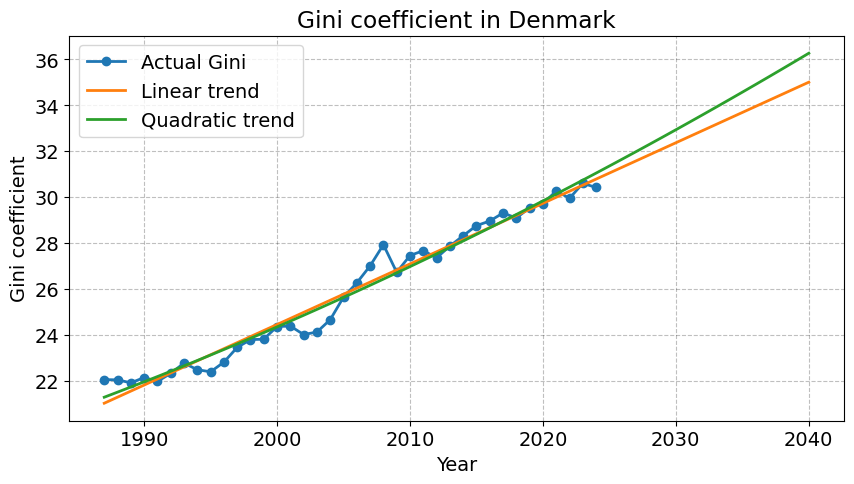

In [110]:
# Create a range of years for the fitted models
years_plot = np.arange(1987, 2041)
t_plot = years_plot - 1987

# Linear fitted values
linear_fit = (
    beta_linear[0]
    + beta_linear[1] * t_plot
)

# Quadratic fitted values
quadratic_fit = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)

fig, ax = plt.subplots(figsize=(10, 5))

# Historical Gini
ax.plot(
    gini['year'],
    gini['gini'],
    marker='o',
    linewidth=2,
    label='Actual Gini'
)

# Linear trend
ax.plot(
    years_plot,
    linear_fit,
    linewidth=2,
    label='Linear trend'
)

# Quadratic trend
ax.plot(
    years_plot,
    quadratic_fit,
    linewidth=2,
    label='Quadratic trend'
)

ax.set_title("Gini coefficient in Denmark")
ax.set_xlabel("Year")
ax.set_ylabel("Gini coefficient")

ax.legend()

plt.show()

* The actual historical Gini values and extend both models out to 2040.

We will examine how well do the two specifications fit the historical data?

We will calculate R^(2) for both models

In [111]:
linear_fitted = (
    beta_linear[0]
    + beta_linear[1] * t
)

quadratic_fitted = (
    beta_quadratic[0]
    + beta_quadratic[1] * t
    + beta_quadratic[2] * t**2
)

In [112]:
ss_total = np.sum((y - np.mean(y))**2)

ss_res_linear = np.sum((y - linear_fitted)**2)
ss_res_quadratic = np.sum((y - quadratic_fitted)**2)

r2_linear = 1 - ss_res_linear / ss_total
r2_quadratic = 1 - ss_res_quadratic / ss_total

print("R² linear:", r2_linear)
print("R² quadratic:", r2_quadratic)

R² linear: 0.9706735862731658
R² quadratic: 0.9725343115088494


We can calculate RMSE as well:

In [113]:
rmse_linear = np.sqrt(np.mean((y - linear_fitted)**2))
rmse_quadratic = np.sqrt(np.mean((y - quadratic_fitted)**2))

print("RMSE linear:", rmse_linear)
print("RMSE quadratic:", rmse_quadratic)

RMSE linear: 0.5023400605969336
RMSE quadratic: 0.4861424888968344


Normally, the quadratic model is expected to be as fit as the linear model in the historical data, because it has an exstra parameter and can capture curvature.

Summary table:

In [114]:
results = pd.DataFrame({
    'Model': ['Linear', 'Quadratic'],
    'R2': [r2_linear, r2_quadratic],
    'RMSE': [rmse_linear, rmse_quadratic],
    'Prediction 2030': [linear_2030, quadratic_2030],
    'Prediction 2040': [linear_2040, quadratic_2040]
})

print(results)

       Model        R2      RMSE  Prediction 2030  Prediction 2040
0     Linear  0.970674  0.502340        32.375386        35.010882
1  Quadratic  0.972534  0.486142        32.940661        36.270979


How well do the two specifications fit the historical data? How much do their predictions differ? Would you trust either of them, and why?

Both the linear and quadratic specifications capture the long run development in the Danish Gini coefficient. The quadratic specification has a better fit to the historical data, during to its higher R^2 and lower RMSE, which is expected during to the the quadratic model is more flexible and can capture the changes in the slope over time. 

However, both models produce increasingly different predictions when extrapolated beyond the observed data. The difference is greater in 2040 than in 2030, because the quadratic term becomes more influential as time increases. 

During to the uncartainty with these predictions, we should be cautious about relying blindly on either models. Both models are estimated based on historical trends and assume these relationships will continue in the future. A quadratic model can produce unrealistic long-run predictions during to the t^(2) term causes the trend to accelerate over time. While the linear model is simpler, which may be more stable when extrapolating, but it assumes that the inequality changes at a constant rate. Neither model accounts for changes in factors that may affect the inequality






### 1.3 Municipalities

1. Compute the correlation between the Gini coefficient and the top 10 percent
share across municipalities. Is it similar to the correlation over time you found
above?

In [123]:
KOMMUNEDK = "000"
ULLIG = "70"

In [124]:
gini_muni = IFOR41.get_data(
    params={
        'table': 'IFOR41',
        'format': 'BULK',
        'lang': 'en',
        'variables': [
            {
                'code': 'KOMMUNEDK',
                'values': ['*']
            },
            {
                'code': 'ULLIG',
                'values': ['70']
            },
            {
                'code': 'Tid',
                'values': ['*']
            }
        ]
    }
)

print(gini_muni.head())
print(gini_muni.columns.tolist())

       KOMMUNEDK             ULLIG   TID INDHOLD
0    All Denmark  Gini coefficient  2016   28.97
1     Copenhagen  Gini coefficient  2016   33.24
2  Frederiksberg  Gini coefficient  2016   34.85
3       Ballerup  Gini coefficient  2016   25.77
4        Brøndby  Gini coefficient  2016   25.71
['KOMMUNEDK', 'ULLIG', 'TID', 'INDHOLD']


In [117]:
gini_muni = gini_muni.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini',
    'KOMMUNEDK': 'municipality'
})

gini_muni['year'] = pd.to_numeric(gini_muni['year'])
gini_muni['gini'] = pd.to_numeric(gini_muni['gini'])

print(gini_muni.head())

    municipality             ULLIG  year   gini
0    All Denmark  Gini coefficient  2016  28.97
1     Copenhagen  Gini coefficient  2016  33.24
2  Frederiksberg  Gini coefficient  2016  34.85
3       Ballerup  Gini coefficient  2016  25.77
4        Brøndby  Gini coefficient  2016  25.71


In [121]:
IFOR32 = DstApi('IFOR32')

print(IFOR32.variable_levels('DECILGEN', language='en'))

     id           text
0   1DC    First decil
1   2DC   Second decil
2   3DC    Third decil
3   4DC   Fourth decil
4   5DC    Fifth decil
5   6DC    Sixth decil
6   7DC  Seventh decil
7   8DC    Eigth decil
8   9DC    Ninth decil
9  10DC    Tenth decil


In [128]:
top10_muni = IFOR32.get_data(
    params={
        'table': 'IFOR32',
        'format': 'BULK',
        'lang': 'en',
        'variables': [
            {
                'code': 'KOMMUNEDK',
                'values': ['*']
            },
            {
                'code': 'DECILGEN',
                'values': ['10DC']
            },
            {
                'code': 'Tid',
                'values': ['*']
            }
        ]
    }
)

print(top10_muni.head())
print(top10_muni.columns.tolist())

   KOMMUNEDK     DECILGEN   TID  INDHOLD
0     Odense  Tenth decil  2013   483490
1  Svendborg  Tenth decil  2013   499484
2   Nordfyns  Tenth decil  2013   461262
3  Langeland  Tenth decil  2013   409603
4        Ærø  Tenth decil  2013   444452
['KOMMUNEDK', 'DECILGEN', 'TID', 'INDHOLD']


In [129]:
top10_muni = top10_muni.rename(columns={
    'KOMMUNEDK': 'municipality',
    'TID': 'year',
    'INDHOLD': 'top10'
})

top10_muni['year'] = pd.to_numeric(top10_muni['year'])
top10_muni['top10'] = pd.to_numeric(top10_muni['top10'])

print(top10_muni.head())

  municipality     DECILGEN  year   top10
0       Odense  Tenth decil  2013  483490
1    Svendborg  Tenth decil  2013  499484
2     Nordfyns  Tenth decil  2013  461262
3    Langeland  Tenth decil  2013  409603
4          Ærø  Tenth decil  2013  444452


Calculate the top 10% share across municipalities

In [130]:
income_deciles = IFOR32.get_data(
    params={
        'table': 'IFOR32',
        'format': 'BULK',
        'lang': 'en',
        'variables': [
            {
                'code': 'KOMMUNEDK',
                'values': ['*']
            },
            {
                'code': 'DECILGEN',
                'values': ['*']
            },
            {
                'code': 'Tid',
                'values': ['*']
            }
        ]
    }
)

print(income_deciles.head())
print(income_deciles.columns.tolist())

  KOMMUNEDK      DECILGEN   TID  INDHOLD
0    Odense  Second decil  2013   123841
1    Odense   Third decil  2013   150153
2    Odense  Fourth decil  2013   170790
3    Odense   Fifth decil  2013   193979
4    Odense   Sixth decil  2013   218942
['KOMMUNEDK', 'DECILGEN', 'TID', 'INDHOLD']


In [131]:
income_deciles = income_deciles.rename(columns={
    'KOMMUNEDK': 'municipality',
    'DECILGEN': 'decile',
    'TID': 'year',
    'INDHOLD': 'income'
})

income_deciles['year'] = pd.to_numeric(income_deciles['year'])
income_deciles['income'] = pd.to_numeric(income_deciles['income'])

In [132]:
total_income = (
    income_deciles
    .groupby(['municipality', 'year'])['income']
    .sum()
    .reset_index(name='total_income')
)

In [158]:
top10_income = income_deciles[
    income_deciles['decile'].astype(str) == 'Tenth decil'
].copy()

top10_income = top10_income.rename(
    columns={'income': 'top10_income'}
)

In [159]:
top10 = pd.merge(
    top10_income[['municipality', 'year', 'top10_income']],
    total_income,
    on=['municipality', 'year'],
    how='inner'
)

In [ ]:
#check
print(income_deciles['decile'].unique())

In [ ]:
#check 
print(income_deciles[['decile']].drop_duplicates())

In [ ]:
#check
print(income_deciles.head(20).to_string())

   municipality         decile  year  income
0        Odense   Second decil  2013  123841
1        Odense    Third decil  2013  150153
2        Odense   Fourth decil  2013  170790
3        Odense    Fifth decil  2013  193979
4        Odense    Sixth decil  2013  218942
5        Odense  Seventh decil  2013  245373
6        Odense    Eigth decil  2013  276747
7        Odense    Ninth decil  2013  320613
8        Odense    Tenth decil  2013  483490
9     Svendborg    First decil  2013   82788
10    Svendborg   Second decil  2013  141075
11    Svendborg    Third decil  2013  162164
12    Svendborg   Fourth decil  2013  180742
13    Svendborg    Fifth decil  2013  202062
14    Svendborg    Sixth decil  2013  223741
15    Svendborg  Seventh decil  2013  247456
16    Svendborg    Eigth decil  2013  276856
17    Svendborg    Ninth decil  2013  321466
18    Svendborg    Tenth decil  2013  499484
19     Nordfyns    First decil  2013  100422


In [ ]:
#check
print(top10_income.head())
print(top10_income.shape)

   municipality       decile  year  top10_income
8        Odense  Tenth decil  2013        483490
18    Svendborg  Tenth decil  2013        499484
28     Nordfyns  Tenth decil  2013        461262
38    Langeland  Tenth decil  2013        409603
48          Ærø  Tenth decil  2013        444452
(3762, 4)


In [161]:
top10['top10_share'] = (
    top10['top10_income'] / top10['total_income'] * 100
)

print(top10.head())

  municipality  year  top10_income  total_income  top10_share
0       Odense  2013        483490       2255077    21.440066
1    Svendborg  2013        499484       2337834    21.365247
2     Nordfyns  2013        461262       2299823    20.056413
3    Langeland  2013        409603       2063714    19.847857
4          Ærø  2013        444452       2120076    20.963965


Combine Gini and top 10%

In [164]:
#check
print(gini_muni.columns.tolist())
print(gini_muni.head())

['KOMMUNEDK', 'ULLIG', 'TID', 'INDHOLD']
       KOMMUNEDK             ULLIG   TID INDHOLD
0    All Denmark  Gini coefficient  2016   28.97
1     Copenhagen  Gini coefficient  2016   33.24
2  Frederiksberg  Gini coefficient  2016   34.85
3       Ballerup  Gini coefficient  2016   25.77
4        Brøndby  Gini coefficient  2016   25.71


In [165]:
gini_muni = gini_muni.rename(columns={
    'KOMMUNEDK': 'municipality',
    'TID': 'year',
    'INDHOLD': 'gini'
})

gini_muni['year'] = pd.to_numeric(gini_muni['year'])
gini_muni['gini'] = pd.to_numeric(gini_muni['gini'])

In [166]:
municipality_data = pd.merge(
    gini_muni[['municipality', 'year', 'gini']],
    top10[['municipality', 'year', 'top10_share']],
    on=['municipality', 'year'],
    how='inner'
)

print(municipality_data.head())
print(municipality_data.shape)

    municipality  year   gini  top10_share
0    All Denmark  2016  28.97    23.383232
1     Copenhagen  2016  33.24    24.913009
2  Frederiksberg  2016  34.85    26.722629
3       Ballerup  2016  25.77    20.532056
4        Brøndby  2016  25.71    20.580151
(3762, 4)


Correlation across municipalities

In [168]:
latest_year = municipality_data['year'].max()

latest = municipality_data[
    municipality_data['year'] == latest_year
].copy()

print("Latest year:", latest_year)
print(latest.head())

Latest year: 2024
       municipality  year   gini  top10_share
3465    All Denmark  2024  30.43    25.121443
3466     Copenhagen  2024  34.97    26.660607
3467  Frederiksberg  2024  36.54    29.120775
3468       Ballerup  2024  26.72    21.570696
3469        Brøndby  2024  26.16    20.506813


In [169]:
correlation_municipalities = latest['gini'].corr(
    latest['top10_share']
)

print(
    "Correlation between Gini and top 10% share:",
    correlation_municipalities
)

Correlation between Gini and top 10% share: 0.9747129559226703


 The correlation between the Gini coefficient and the income share of the richest 10% is 0.975, which indicating a strong positive relationship. This means that municipalities with higher gini coefficients, will also generally lead to a higher share of income going to the richest 10%.


2. Find the 10 most and the 10 least unequal municipalities in the most recent
year, and illustrate them in a figure. Describe the pattern.

Use the Gini coefficient in the latest year.

In [170]:
most_unequal = latest.sort_values(
    'gini',
    ascending=False
).head(10)

print(most_unequal[
    ['municipality', 'gini', 'top10_share']
])

        municipality   gini  top10_share
3471        Gentofte  49.04    41.033069
3489       Rudersdal  47.31    40.510763
3529           Vejen  46.32    43.818879
3488        Hørsholm  40.07    32.944553
3478  Lyngby-Taarbæk  39.28    31.501149
3467   Frederiksberg  36.54    29.120775
3466      Copenhagen  34.97    26.660607
3547          Aarhus  33.43    26.307954
3485     Fredensborg  32.76    27.717180
3486       Helsingør  30.55    25.752239


In [171]:
least_unequal = latest.sort_values(
    'gini',
    ascending=True
).head(10)

print(least_unequal[
    ['municipality', 'gini', 'top10_share']
])

         municipality   gini  top10_share
3514  Faaborg-Midtfyn  23.77    20.294854
3490           Egedal  23.85    20.277518
3511         Bornholm  24.03    21.065780
3500             Faxe  24.09    20.073904
3494          Halsnæs  24.41    20.463575
3541         Favrskov  24.41    20.913836
3513           Assens  24.46    20.900440
3550        Hedensted  24.58    21.443534
3475      Albertslund  24.66    19.990548
3542            Odder  24.70    21.232868


Exstra check 

In [172]:
selected_municipalities = pd.concat([
    most_unequal['municipality'],
    least_unequal['municipality']
]).unique()

selected_series = municipality_data[
    municipality_data['municipality'].isin(selected_municipalities)
]

print(
    selected_series[
        ['municipality', 'year', 'gini']
    ].sort_values(['municipality', 'year'])
)

     municipality  year   gini
1666       Aarhus  1987  22.10
280        Aarhus  1988  22.62
478        Aarhus  1989  22.59
3052       Aarhus  1990  23.10
2557       Aarhus  1991  23.47
...           ...   ...    ...
2638        Vejen  2020  25.74
757         Vejen  2021  26.22
1054        Vejen  2022  26.74
2935        Vejen  2023  47.95
3529        Vejen  2024  46.32

[760 rows x 3 columns]


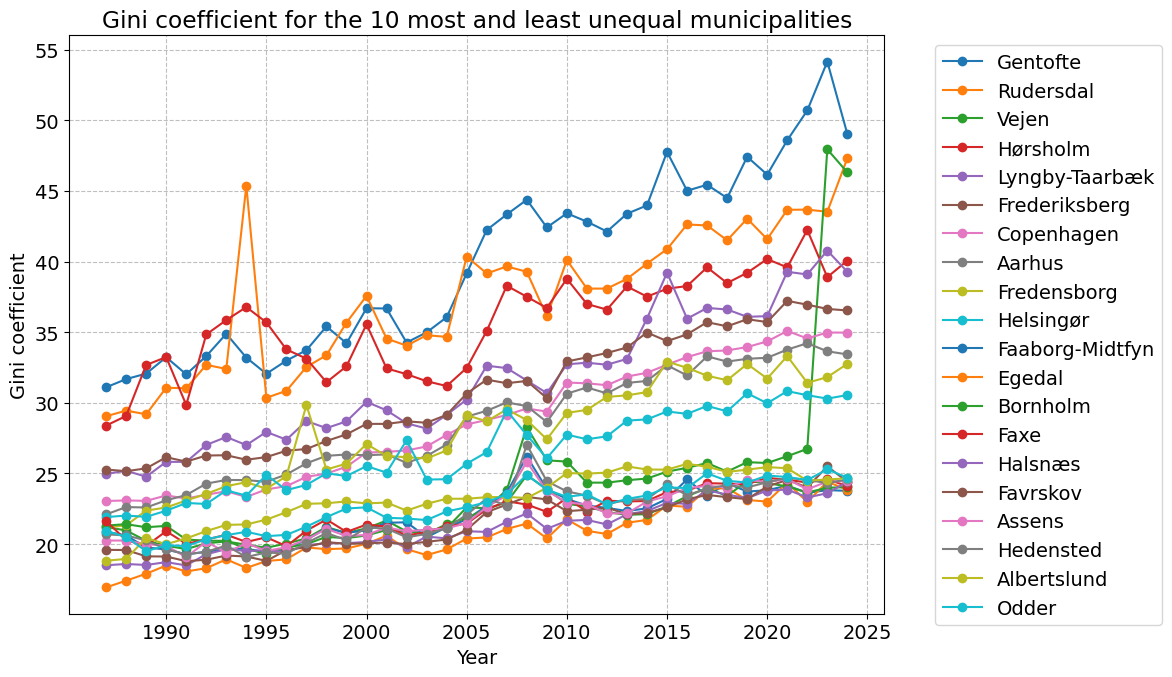

In [173]:
fig, ax = plt.subplots(figsize=(12, 7))

for municipality in selected_municipalities:
    data = selected_series[
        selected_series['municipality'] == municipality
    ].sort_values('year')
    
    ax.plot(
        data['year'],
        data['gini'],
        marker='o',
        linewidth=1.5,
        label=municipality
    )

ax.set_title("Gini coefficient for the 10 most and least unequal municipalities")
ax.set_xlabel("Year")
ax.set_ylabel("Gini coefficient")

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

3. Find the municipalities with the largest and the smallest change in the Gini
coefficient. Illustrate and comment.

In [174]:
first_year = municipality_data['year'].min()
last_year = municipality_data['year'].max()

print("First year:", first_year)
print("Last year:", last_year)

First year: 1987
Last year: 2024


In [176]:
gini_change = municipality_data.pivot(
    index='municipality',
    columns='year',
    values='gini'
)

In [177]:
gini_change['change'] = (
    gini_change[last_year]
    - gini_change[first_year]
)

In [180]:
largest_increase = gini_change.sort_values(
    'change',
    ascending=False
).head(10)

print(largest_increase[
    [first_year, last_year, 'change']
])

year             1987   2024  change
municipality                        
Vejen           21.20  46.32   25.12
Rudersdal       29.05  47.31   18.26
Gentofte        31.10  49.04   17.94
Lyngby-Taarbæk  24.97  39.28   14.31
Copenhagen      23.05  34.97   11.92
Hørsholm        28.39  40.07   11.68
Fredensborg     21.17  32.76   11.59
Aarhus          22.10  33.43   11.33
Frederiksberg   25.28  36.54   11.26
Vallensbæk      15.90  26.70   10.80


In [181]:
smallest_change = gini_change.sort_values(
    'change',
    ascending=True
).head(10)

print(smallest_change[
    [first_year, last_year, 'change']
])

year              1987   2024  change
municipality                         
Fanø             25.67  26.34    0.67
Ærø              24.63  26.98    2.35
Faxe             21.64  24.09    2.45
Læsø             22.81  25.41    2.60
Bornholm         21.31  24.03    2.72
Faaborg-Midtfyn  20.88  23.77    2.89
Sorø             22.24  25.16    2.92
Stevns           21.35  24.77    3.42
Mariagerfjord    22.31  25.98    3.67
Odder            20.93  24.70    3.77


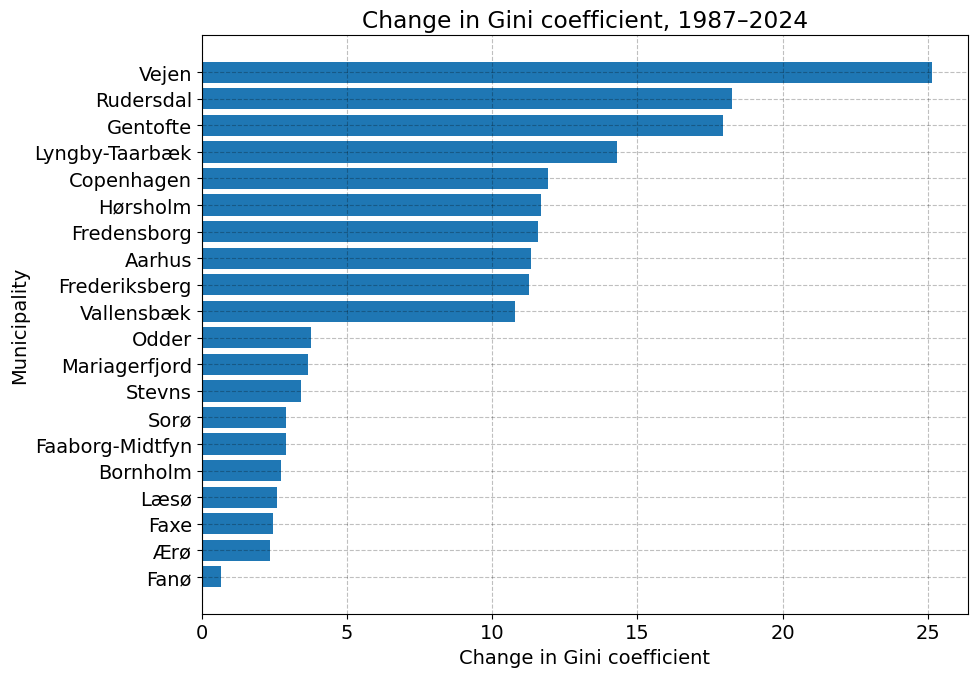

In [182]:
change_plot = pd.concat([
    largest_increase[['change']],
    smallest_change[['change']]
])

change_plot = change_plot.sort_values('change')

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    change_plot.index,
    change_plot['change']
)

ax.set_title(
    f"Change in Gini coefficient, {first_year}–{last_year}"
)

ax.set_xlabel("Change in Gini coefficient")
ax.set_ylabel("Municipality")

plt.tight_layout()
plt.show()

1.4 Extension

Find some other information at the municipality level and relate it to the level of the
Gini coefficient or to its change over time.
Note: This is intended as an open question, and we encourage you to be creative.

We can use IFOR32 to calculate average income. Reseach is there a relationship between average income and the Gini coefficient across Danish municipalities?

In [183]:
income_deciles

,municipality,decile,year,income
0,Odense,Second decil,2013,123841
1,Odense,Third decil,2013,150153
2,Odense,Fourth decil,2013,170790
3,Odense,Fifth decil,2013,193979
4,Odense,Sixth decil,2013,218942
...,...,...,...,...
37615,Nyborg,Seventh decil,2017,260847
37616,Nyborg,Eigth decil,2017,290986
37617,Nyborg,Ninth decil,2017,335590
37618,Nyborg,Tenth decil,2017,500383


In [184]:
average_income = (
    income_deciles
    .groupby(['municipality', 'year'])['income']
    .mean()
    .reset_index(name='average_income')
)

print(average_income.head())

  municipality  year  average_income
0     Aabenraa  1987         87644.5
1     Aabenraa  1988         92660.9
2     Aabenraa  1989         98305.1
3     Aabenraa  1990        101910.8
4     Aabenraa  1991        107817.7


In [185]:
latest_year = municipality_data['year'].max()

print("Latest year:", latest_year)

Latest year: 2024


In [186]:
latest_gini = municipality_data[
    municipality_data['year'] == latest_year
].copy()

latest_income = average_income[
    average_income['year'] == latest_year
].copy()

In [187]:
# Merge Gini and income

extension = pd.merge(
    latest_gini[['municipality', 'year', 'gini']],
    latest_income[['municipality', 'year', 'average_income']],
    on=['municipality', 'year'],
    how='inner'
)

print(extension.head())
print(extension.shape)

    municipality  year   gini  average_income
0    All Denmark  2024  30.43        339542.6
1     Copenhagen  2024  34.97        340949.1
2  Frederiksberg  2024  36.54        404647.2
3       Ballerup  2024  26.72        334083.8
4        Brøndby  2024  26.16        289680.8
(99, 4)


In [188]:
# The correlation

correlation = extension['gini'].corr(
    extension['average_income']
)

print("Correlation:", correlation)

Correlation: 0.8226204851790524


We can see that the corralation is 0.82, which means there is a positive relationship between average income and inequality. Municipalities with higher average income tend to have higher Gini coefficients.

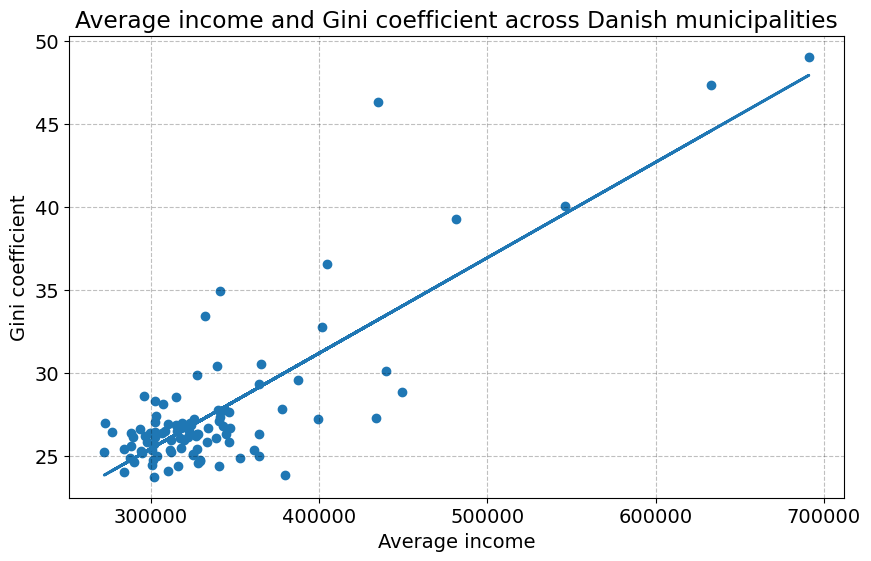

In [191]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    extension['average_income'],
    extension['gini']
)

ax.set_title(
    'Average income and Gini coefficient across Danish municipalities'
)

ax.set_xlabel('Average income')
ax.set_ylabel('Gini coefficient')

x = extension['average_income']
y = extension['gini']

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2
)

plt.show()

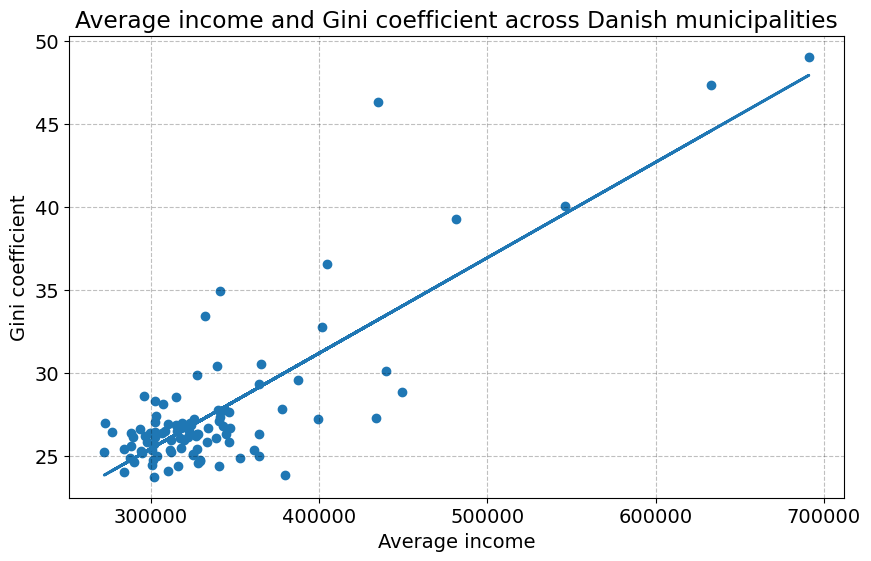

In [192]:
fig, ax = plt.subplots(figsize=(10, 6))

x = extension['average_income']
y = extension['gini']

ax.scatter(x, y)

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2
)

ax.set_title(
    'Average income and Gini coefficient across Danish municipalities'
)

ax.set_xlabel('Average income')
ax.set_ylabel('Gini coefficient')

plt.show()

Rewrite: Extension: Average income and inequality

To extend the analysis, I investigate whether average income is related to inequality across Danish municipalities. I use the municipality-level Gini coefficient as the measure of inequality and average income as an additional economic indicator.

The correlation between average income and the Gini coefficient is 0.82. This indicates a strong positive relationship.

The scatter plot shows that municipalities with higher average income tend to have higher Gini coefficients. However, the relationship is not perfect, indicating that average income alone cannot explain differences in inequality between municipalities.

This suggests that inequality depends on more than the overall income level of a municipality. Other factors such as employment, education, demographics, housing prices, and the concentration of very high incomes may also contribute to differences in inequality.

Even better: investigate changes over time

In [196]:
# First and last available year
first_year = municipality_data['year'].min()
last_year = municipality_data['year'].max()

print("First year:", first_year)
print("Last year:", last_year)

First year: 1987
Last year: 2024


In [197]:
gini_change = (
    municipality_data[
        municipality_data['year'].isin([first_year, last_year])
    ]
    .pivot(
        index='municipality',
        columns='year',
        values='gini'
    )
    .reset_index()
)

gini_change['gini_change'] = (
    gini_change[last_year] - gini_change[first_year]
)

print(gini_change.head())

year municipality   1987   2024  gini_change
0        Aabenraa  21.33  28.14         6.81
1         Aalborg  21.01  28.59         7.58
2          Aarhus  22.10  33.43        11.33
3     Albertslund  18.82  24.66         5.84
4     All Denmark  22.07  30.43         8.36


In [198]:
income_change = (
    average_income[
        average_income['year'].isin([first_year, last_year])
    ]
    .pivot(
        index='municipality',
        columns='year',
        values='average_income'
    )
    .reset_index()
)

income_change['income_change'] = (
    income_change[last_year] - income_change[first_year]
)

print(income_change.head())

year municipality     1987      2024  income_change
0        Aabenraa  87644.5  307494.2       219849.7
1         Aalborg  87911.5  314877.8       226966.3
2          Aarhus  90286.9  332076.0       241789.1
3     Albertslund  96895.3  290110.6       193215.3
4     All Denmark  91898.8  339542.6       247643.8


In [199]:
changes = pd.merge(
    gini_change[['municipality', 'gini_change']],
    income_change[['municipality', 'income_change']],
    on='municipality',
    how='inner'
)

print(changes.head())
print(changes.shape)

year municipality  gini_change  income_change
0        Aabenraa         6.81       219849.7
1         Aalborg         7.58       226966.3
2          Aarhus        11.33       241789.1
3     Albertslund         5.84       193215.3
4     All Denmark         8.36       247643.8
(99, 3)


In [200]:
change_correlation = changes['gini_change'].corr(
    changes['income_change']
)

print("Correlation between changes:", change_correlation)

Correlation between changes: 0.7297837053167042


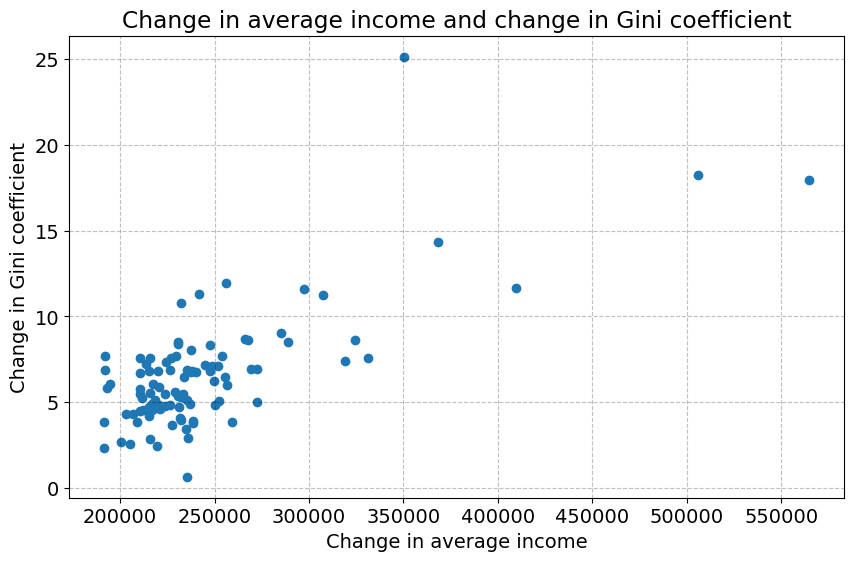

In [201]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    changes['income_change'],
    changes['gini_change']
)

ax.set_title(
    'Change in average income and change in Gini coefficient'
)

ax.set_xlabel(
    'Change in average income'
)

ax.set_ylabel(
    'Change in Gini coefficient'
)

plt.show()

## 2 Simulating the income distribution

2.1 The model